데이터 수집 -> 정제/EDA -> 전처리 -> 데이터 분리(학습/테스트) -> 모델 선정 -> 학습 -> 평가 -> 피드백

In [86]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 수집

데이터 : PowerCo.ltd의 고객 이탈률
- https://www.kaggle.com/datasets/sharmadeepankaj/customer-churn-of-powerco-ltd?select=client_data.csv

### target = churn (향후 3개월 동안 고객 이탈 여부)
### price_data.csv : 시간의 흐름에 따른 전기 및 가스 가격
| 컬럼명(한글) | 컬럼명(영어) | 설명(한글) | 분포 | 데이터 타입 |
|---|---|---|---|---|
| 고객사 ID | id | 고객사(회사) 고유 식별자 | 16,096개 고객, 중복 존재 | object |
| 가격 기준일 | price_date | 가격이 적용되는 기준 날짜 | 2015-01-01 ~ 2015-12-01 (월 단위) | object |
| 비수기 에너지 변동가 | price_off_peak_var | 비수기(1구간) 에너지 변동 가격 | 0.10~0.16 집중, max ≈ 0.28 | float64 |
| 피크 에너지 변동가 | price_peak_var | 피크(2구간) 에너지 변동 가격 | 다수 0값, 유효값 0.08~0.12 | float64 |
| 중간피크 에너지 변동가 | price_mid_peak_var | 중간피크(3구간) 에너지 변동 가격 | 대부분 0, 일부 0.06~0.10 | float64 |
| 비수기 전력 고정가 | price_off_peak_fix | 비수기(1구간) 전력 고정 가격 | 40~46 집중, max ≈ 59.4 | float64 |
| 피크 전력 고정가 | price_peak_fix | 피크(2구간) 전력 고정 가격 | 다수 0, 일부 24~26 / 35~36 | float64 |
| 중간피크 전력 고정가 | price_mid_peak_fix | 중간피크(3구간) 전력 고정 가격 | 다수 0, 일부 16~17 | float64 |

### client_data.csv : 고객의 일반 정보
| 컬럼명(한글) | 컬럼명(영어) | 설명(한글) | 분포 | 데이터 타입 |
|---|---|---|---|---|
| 고객사 ID | id | 고객사 고유 식별자 | 14,606개 모두 고유값 | object |
| 판매 채널 | channel_sales | 고객이 유입된 판매 채널 코드 | 3개 주요 범주 (약 46% / 28% / 26%) | object |
| 연간 전기 소비량 | cons_12m | 지난 12개월간 전기 소비량 | 강한 우측 치우침, max ≈ 6.21M | int64 |
| 연간 가스 소비량 | cons_gas_12m | 지난 12개월간 가스 소비량 | 강한 우측 치우침, max ≈ 4.15M | int64 |
| 전월 전기 소비량 | cons_last_month | 지난달 전기 소비량 | 우측 치우침, max ≈ 771K | int64 |
| 계약 활성일 | date_activ | 계약이 시작된 날짜 | 2003-05-09 ~ 2014-09-01 | object |
| 계약 종료일 | date_end | 계약이 종료된 날짜 | 2016-01-28 ~ 2017-06-13 | object |
| 상품 수정일 | date_modif_prod | 상품이 마지막으로 수정된 날짜 | 2003-05-09 ~ 2016-01-29 | object |
| 계약 갱신일 | date_renewal | 다음 계약 갱신 예정일 | 2013-06-26 ~ 2016-01-28 | object |
| 예상 전기 소비량(12개월) | forecast_cons_12m | 향후 12개월 예상 전기 소비량 | 대부분 저값, max ≈ 82.9K | float64 |
| 예상 전기 소비량(1년) | forecast_cons_year | 향후 1년 예상 전기 소비량 | 대부분 저값, max ≈ 175K | int64 |
| 예상 에너지 할인 | forecast_discount_energy | 향후 적용될 할인 금액 | 0~30 구간 집중 | float64 |
| 예상 계량기 임대료 | forecast_meter_rent_12m | 향후 12개월 계량기 임대료 | 0~30 구간 집중 | float64 |
| 비수기 에너지 가격 | forecast_price_energy_off_peak | 비수기 에너지 단가 예측 | 0~600 구간 집중 | float64 |
| 피크 에너지 가격 | forecast_price_energy_peak | 피크 시간대 에너지 단가 예측 | 0.11~0.18 집중 | float64 |
| 비수기 전력 가격 | forecast_price_pow_off_peak | 비피크 시간대 전력 단가 | 0.08~0.12 집중 | float64 |
| 가스 고객 여부 | has_gas | 가스 상품 가입 여부 | True 18% / False 82% | object |
| 유료 소비량 | imp_cons | 실제 청구 기준 소비량 | 우측 치우침, max ≈ 15K | float64 |
| 전력 총마진 | margin_gross_pow_ele | 전력 구독 총 마진 | 0~375 범위 집중 | float64 |
| 전력 순마진 | margin_net_pow_ele | 전력 구독 순 마진 | 총마진과 유사 분포 | float64 |
| 활성 상품 수 | nb_prod_act | 활성화된 상품 및 서비스 수 | 1~2개 구간 집중 | int64 |
| 총 순마진 | net_margin | 고객 전체 순마진 | 극단적 우측 치우침 | float64 |
| 가입 연수 | num_years_antig | 고객 가입 후 경과 연수 | 2~7년 구간 집중 | int64 |
| 가입 캠페인 | origin_up | 최초 가입 캠페인 코드 | 3개 주요 그룹 | object |
| 계약 전력량 | pow_max | 계약된 최대 전력량 | 3~320 범위 | float64 |
| 이탈 여부 | churn | 향후 3개월 내 이탈 여부 | 1 약 10% / 0 약 90% | int64 |

In [27]:
price_df = pd.read_csv('./data/price_data.csv')
price_df

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
...,...,...,...,...,...,...,...,...
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2015-08-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2015-09-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2015-10-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2015-11-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555


In [12]:
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [28]:
client_df = pd.read_csv('./data/client_data.csv')
client_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,t,0.00,27.88,27.88,2,381.77,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,f,15.94,0.00,0.00,1,90.34,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,f,18.05,39.84,39.84,1,20.38,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,f,0.00,13.08,13.08,1,0.96,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0


In [14]:
client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [15]:
# # 금액 부분만 리스트 만들기
# price_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

# # mean(전반적 수준)
# mean = price_df.groupby('id')[price_cols].mean()

# # last(최근 상태)
# last = price_df.groupby('id')[price_cols].last()

# # std(변동성)
# std = price_df.groupby('id')[price_cols].std()

# # mean, last, std 새로 만들 컬럼명 변경해주기
# mean.columns = [c + '_mean' for c in mean.columns]
# last.columns = [c + '_last' for c in last.columns]
# std.columns = [c + '_std' for c in std.columns]

# # price_df에 이어 붙이기
# price_df = pd.concat([mean, last, std], axis=1).reset_index()

# price_df

In [29]:
# datetime으로 변환
price_df["price_date"] = pd.to_datetime(price_df["price_date"])

# 정렬
price_df = price_df.sort_values(["id", "price_date"])

# 현재 컬럼
price_cols = [
    "price_off_peak_var", "price_peak_var", "price_mid_peak_var",
    "price_off_peak_fix", "price_peak_fix", "price_mid_peak_fix"
]

# id를 기준으로 현재 컬럼들을 mean, last, std로 그룹화하기
price_feat = (
    price_df
    .groupby("id")[price_cols]
    .agg(["mean", "last", "std"])
)

# 컬럼명 정리
price_feat.columns = [
    f"{col}_{stat}" for col, stat in price_feat.columns
]

price_merge = price_feat.reset_index()

price_merge

,id,price_off_peak_var_mean,price_off_peak_var_last,price_off_peak_var_std,price_peak_var_mean,price_peak_var_last,price_peak_var_std,price_mid_peak_var_mean,price_mid_peak_var_last,price_mid_peak_var_std,price_off_peak_fix_mean,price_off_peak_fix_last,price_off_peak_fix_std,price_peak_fix_mean,price_peak_fix_last,price_peak_fix_std,price_mid_peak_fix_mean,price_mid_peak_fix_last,price_mid_peak_fix_std
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.119906,0.003976,0.103794,0.101673,0.001989,0.073160,0.073719,0.001368,40.701732,40.728885,6.341481e-02,24.421038,24.43733,0.038049,16.280694,16.291555,0.025366
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.143943,0.002197,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.385450,44.444710,8.753223e-02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.201280,0.026008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.319710,45.944710,7.723930e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.113068,0.005049,0.098292,0.095385,0.002580,0.069032,0.069409,0.000403,40.647427,40.728885,8.507958e-02,24.388455,24.43733,0.051048,16.258971,16.291555,0.034032
4,00114d74e963e47177db89bc70108537,0.147926,0.145440,0.002202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.266930,44.266930,5.908392e-07,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16091,ffef185810e44254c3a4c6395e6b4d8a,0.138863,0.112488,0.026238,0.115125,0.094804,0.020548,0.080780,0.068829,0.012503,40.896427,40.728885,1.749923e-01,24.637456,24.43733,0.209025,16.507972,16.291555,0.226040
16092,fffac626da707b1b5ab11e8431a4d0a2,0.147137,0.145047,0.002098,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.311375,44.444710,8.040373e-02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
16093,fffc0cacd305dd51f316424bbb08d1bd,0.153879,0.151399,0.003044,0.129497,0.126871,0.002447,0.094842,0.091394,0.004310,41.160171,41.228885,8.491973e-02,24.895768,24.93733,0.051364,16.763569,16.791555,0.034586
16094,fffe4f5646aa39c7f97f95ae2679ce64,0.123858,0.118175,0.004600,0.103499,0.100491,0.002397,0.073735,0.074516,0.000471,40.606699,40.728885,7.368063e-02,24.364017,24.43733,0.044209,16.242678,16.291555,0.029474


In [30]:
# price_merge랑 client_data 합치기
client_price_df = pd.merge(client_df, price_merge, on='id', how='left')
client_price_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,price_mid_peak_var_std,price_off_peak_fix_mean,price_off_peak_fix_last,price_off_peak_fix_std,price_peak_fix_mean,price_peak_fix_last,price_peak_fix_std,price_mid_peak_fix_mean,price_mid_peak_fix_last,price_mid_peak_fix_std
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.020983,40.942265,44.266930,1.050136e+00,22.352010,0.000000,7.039226,14.901340,0.000000,4.692817
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000,44.311375,44.444710,8.040385e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000,44.385450,44.444710,8.753223e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000,44.400265,44.444710,8.040349e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.001588,40.688156,40.728885,7.368135e-02,24.412893,24.437330,0.044209,16.275263,16.291555,0.029473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,0.000000,44.370635,44.444710,9.154352e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,0.000128,59.015674,59.173468,1.165389e-01,36.393379,36.490689,0.071868,8.345418,8.367731,0.016479
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,0.001368,40.701732,40.728885,6.341481e-02,24.421038,24.437330,0.038049,16.280694,16.291555,0.025366
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,0.000000,44.311375,44.444710,8.040379e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


가격 차이 확인해보기(최근 - 평균) : 비수기때 12월에 금액이 평균보다 얼마나 변동되었는가
- 결과값 > 0 : 인상됨 => 이탈 위험성 있음
- 결과값 < 0 : 인하됨

In [31]:
client_price_df['var_diff'] = client_price_df['price_off_peak_var_last'] - client_price_df['price_off_peak_var_mean']
client_price_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,price_off_peak_fix_mean,price_off_peak_fix_last,price_off_peak_fix_std,price_peak_fix_mean,price_peak_fix_last,price_peak_fix_std,price_mid_peak_fix_mean,price_mid_peak_fix_last,price_mid_peak_fix_std,var_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,40.942265,44.266930,1.050136e+00,22.352010,0.000000,7.039226,14.901340,0.000000,4.692817,0.021246
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,44.311375,44.444710,8.040385e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002009
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,44.385450,44.444710,8.753223e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002714
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,44.400265,44.444710,8.040349e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002624
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,40.688156,40.728885,7.368135e-02,24.412893,24.437330,0.044209,16.275263,16.291555,0.029473,-0.004268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,44.370635,44.444710,9.154352e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.003952
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,59.015674,59.173468,1.165389e-01,36.393379,36.490689,0.071868,8.345418,8.367731,0.016479,-0.004447
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,40.701732,40.728885,6.341481e-02,24.421038,24.437330,0.038049,16.280694,16.291555,0.025366,-0.004432
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,44.311375,44.444710,8.040379e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002009


In [32]:
client_price_df['fix_diff'] = client_price_df['price_off_peak_fix_last'] - client_price_df['price_off_peak_fix_mean']
client_price_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,price_off_peak_fix_last,price_off_peak_fix_std,price_peak_fix_mean,price_peak_fix_last,price_peak_fix_std,price_mid_peak_fix_mean,price_mid_peak_fix_last,price_mid_peak_fix_std,var_diff,fix_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,44.266930,1.050136e+00,22.352010,0.000000,7.039226,14.901340,0.000000,4.692817,0.021246,3.324664e+00
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,44.444710,8.040385e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002009,1.333347e-01
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,44.444710,8.753223e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002714,5.925960e-02
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,44.444710,8.040349e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002624,4.444470e-02
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,40.728885,7.368135e-02,24.412893,24.437330,0.044209,16.275263,16.291555,0.029473,-0.004268,4.072890e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,44.444710,9.154352e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.003952,7.407460e-02
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,59.173468,1.165389e-01,36.393379,36.490689,0.071868,8.345418,8.367731,0.016479,-0.004447,1.577945e-01
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,40.728885,6.341481e-02,24.421038,24.437330,0.038049,16.280694,16.291555,0.025366,-0.004432,2.715260e-02
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,44.444710,8.040379e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.002009,1.333346e-01


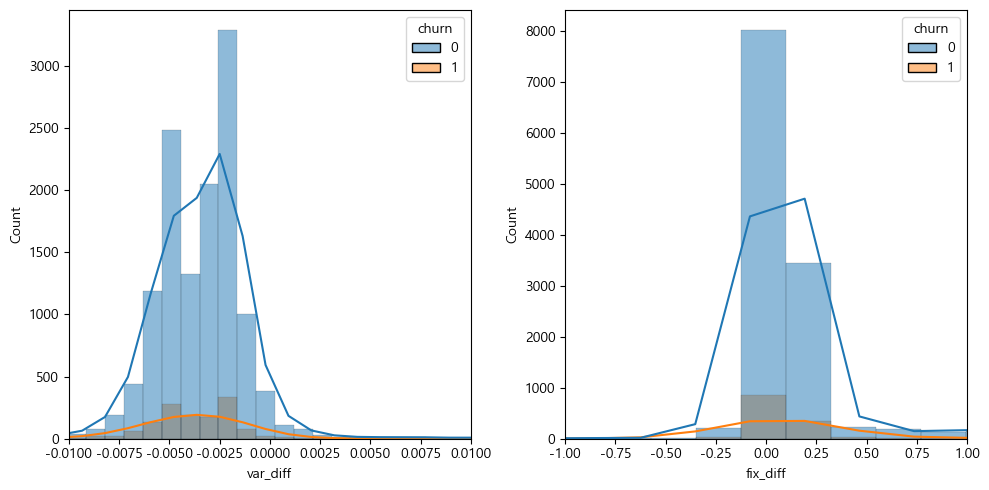

In [ ]:
# 가격 변동과 이탈 여부에 따른 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.subplot(1,2,1)
sns.histplot(data=client_price_df, x='var_diff', hue='churn', kde=True)
plt.xlim(-0.01, 0.01)

plt.subplot(1,2,2)
sns.histplot(data=client_price_df, x='fix_diff', hue='churn', kde=True)
plt.xlim(-1, 1)

plt.tight_layout()
plt.show()

히스토그램을 통해 확인한 결과
- var_diff : 
    - 대부분의 고객은 최근 변동요금이 평균과 큰 차이를 보이지 않음
    - 인하된 고객이 상대적으로 많음
    - 변동요금의 인상이 이탈이 주요 원인이 아닌 것 같음

- fix_diff : 
    - 대부분의 고객은 최근 고정요금이 평균과 비슷하게 유지됨
    - 인상된 고객이 일부 있음
    - 고정요금의 인상이 이탈이 주요 원인이 아닌 것 같음

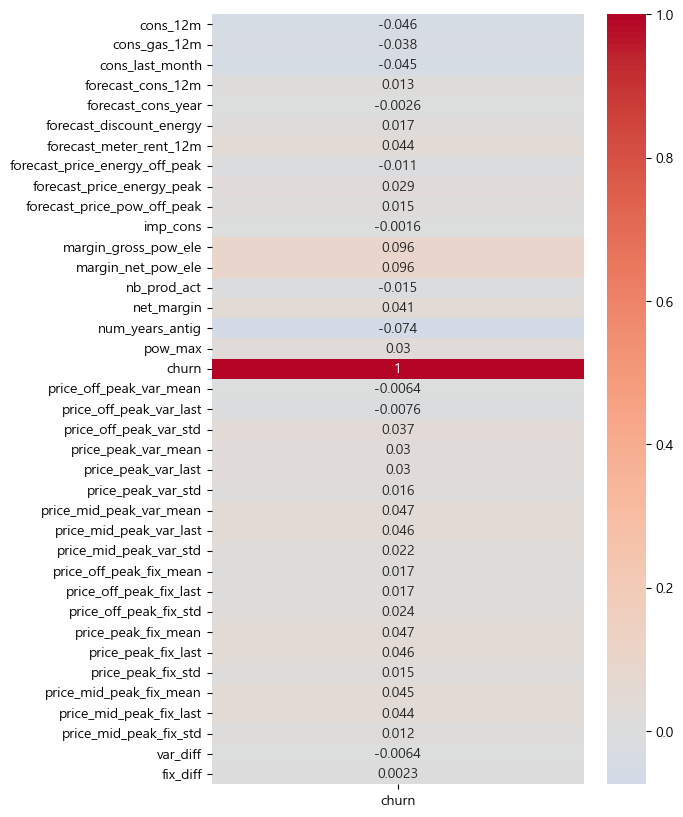

In [81]:
# 숫자형 컬럼만 선택
num_df = client_price_df.select_dtypes(include='number')

# 상관관계 계산
corr = num_df.corr()

# churn과의 상관관계 확인
corr['churn'].sort_values(ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(
    corr[['churn']],
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.show()

히트맵을 통해 확인한 결과 
- var_diff /  fix_diff 두 컬럼은 위에서 확인한 것과 동일하게 상관관계가 거의 없음
- 가입연수 num_years_antig / 마진 관련 margin_* 변수들이 더 상관관계가 있음

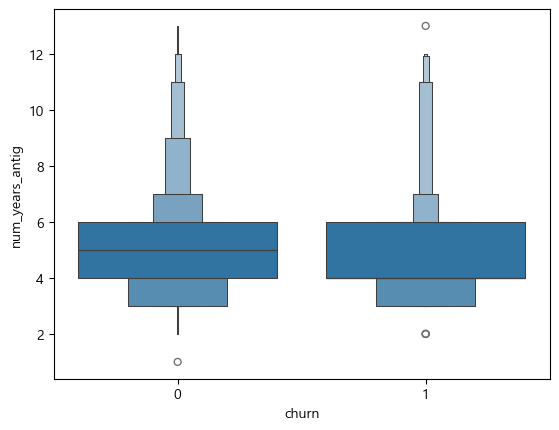

In [82]:
# num_years_antig 시각화
sns.boxenplot(data=client_price_df, x='churn', y='num_years_antig')
plt.show()

박스플롯을 통해 확인한 결과
- 가입연수와 이탈 여부의 관계
    - 가입연수가 오래된 고객이라고해서 이탈이 적다고 할 수 없음
    - 그렇다고 신규고객이라고해서 이탈이 많다고도할 수 없음


# 2. 데이터 분리
- 학습데이터 X : 숫자인 컬럼만 선택 후 target(이탈 여부) 컬럼 삭제

In [87]:
from sklearn.model_selection import train_test_split


In [85]:
# 학습데이터 / 테스트데이터 분리
X = client_price_df.select_dtypes(include=['number']).drop(['churn'], axis=1)
y = client_price_df['churn']

# 학습 데이터(8) : 테스트 데이터(2) => y의 비율 유지해주기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print(f'X_train : {len(X_train)}개, X_test : {(len(X_test))}개, y_train : {len(y_train)}개 , y_test : {len(y_test)}개')

X_train : 11684개, X_test : 2922개, y_train : 11684개 , y_test : 2922개


# 3. 모델 선정 & 학습

In [100]:
from sklearn.ensemble import RandomForestClassifier     # 랜덤 포레스트
from sklearn.linear_model import LogisticRegression     # 로지스틱 회귀 분류 모델
from sklearn.naive_bayes import GaussianNB              # 나이브 베이지 분류기
from sklearn.svm import SVC                             # 서포트벡터머신 분류모델
from sklearn.tree import DecisionTreeClassifier         # 의사결정나무
# from xgboost import XGBClassifier                       # XGBoost 부스팅모델
from sklearn.preprocessing import StandardScaler

# 평가지표 
from sklearn.metrics import (
    accuracy_score,         # 정확도
    precision_score,
    recall_score,           # 재현율
    f1_score,               # F1 스코어
    classification_report,  # 분류 평가 보고서
    confusion_matrix        # 혼동행렬 지표
)

In [107]:
# 스케일링
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)


# 모델 생성 및 학습
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaler, y_train)

# 예측
y_pred_lr = lr_model.predict(X_test_scaler)

# 평가 지표 
test_accuracy = accuracy_score(y_test, y_pred_lr)
test_precision = precision_score(y_test, y_pred_lr)
test_recall = recall_score(y_test, y_pred_lr)
test_f1 = f1_score(y_test, y_pred_lr)

print(f"정확도 (Accuracy): {test_accuracy:.4f}")
print(f"정밀도 (Precision): {test_precision:.4f}")
print(f"재현율 (Recall): {test_recall:.4f}")
print(f"F1_Score : {test_f1:.4f}")


정확도 (Accuracy): 0.9025
정밀도 (Precision): 0.3333
재현율 (Recall): 0.0035
F1_Score : 0.0070


In [ ]:
# 모델 생성 및 학습
lr_model = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
lr_model.fit(X_train_scaler, y_train)

# 예측
y_pred_lr = lr_model.predict(X_test_scaler)

# 평가 지표 
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(f"정확도 (Accuracy): {accuracy:.4f}")
print(f"정밀도 (Precision): {precision:.4f}")
print(f"재현율 (Recall): {recall:.4f}")
print(f"F1_Score : {f1:.4f}")

정확도 (Accuracy): 0.6246
정밀도 (Precision): 0.1399
재현율 (Recall): 0.5563
F1_Score : 0.2236
